<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/transcriptomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Setup & Academic Visualization Styling
This block loads the essential data-wrangling and plotting packages while setting up a high-resolution, peer-review-ready graphic aesthetic.

In [38]:
# BLOCK 1: Environment Setup & Scientific Theming
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Install scikit-bio quietly to handle multivariate distance matrices
!pip install scikit-bio --quiet
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

global_fig_size = (10, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("✨ Block 1: Global environment and styling configured successfully.")

✨ Block 1: Global environment and styling configured successfully.


# Block 2: Data Loading & Phenotype Mapping
This block loads your wide CSV file and uses a conditional function to split your biological samples exactly as you defined: pl_101 to pl_107 are tagged as HF, and pl_111 to pl_119 are tagged as NF.

In [30]:
# BLOCK 2: Data Loading & Conditional Phenotype Assignment

# 1. Load the wide-format read proportion dataset
csv_filename = "symbiont_species_read_proportions_wide.csv"
df = pd.read_csv(csv_filename)

# Clean column headers and sample string IDs of any hidden spaces
df.columns = df.columns.str.strip()
df['sample'] = df['sample'].astype(str).str.strip()

# 2. Map sample IDs to host phenotypic cohorts (HF vs NF)
def assign_morph(sample_id):
    # Extract the numeric part of the sample label (e.g., "pl_101" -> 101)
    try:
        num = int(sample_id.split('_')[1])
        if 101 <= num <= 107:
            return 'HF'
        elif 111 <= num <= 119:
            return 'NF'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

df['morph'] = df['sample'].apply(assign_morph)

# Filter out any unmapped validation rows if present
df = df[df['morph'] != 'Unknown'].copy()

# Sort data to ensure crisp block grouping on the X-axis
df = df.sort_values(by=['morph', 'sample']).reset_index(drop=True)

print(f"📊 Block 2: Successfully loaded {len(df)} larval profiles.")
print(df[['sample', 'morph']])

📊 Block 2: Successfully loaded 10 larval profiles.
   sample morph
0  pl_101    HF
1  pl_102    HF
2  pl_104    HF
3  pl_106    HF
4  pl_107    HF
5  pl_111    NF
6  pl_112    NF
7  pl_113    NF
8  pl_118    NF
9  pl_119    NF


# Block 3: Layout Option A – Faceted Individual Profiles
This script improves your collaborator’s plot by splitting the single continuous row into side-by-side subpanels. This visually isolates the HF block from the NF block so reviewers can immediately scan and see that the colors match perfectly.

/tmp/ipykernel_1342/723218966.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(taxa_cols))


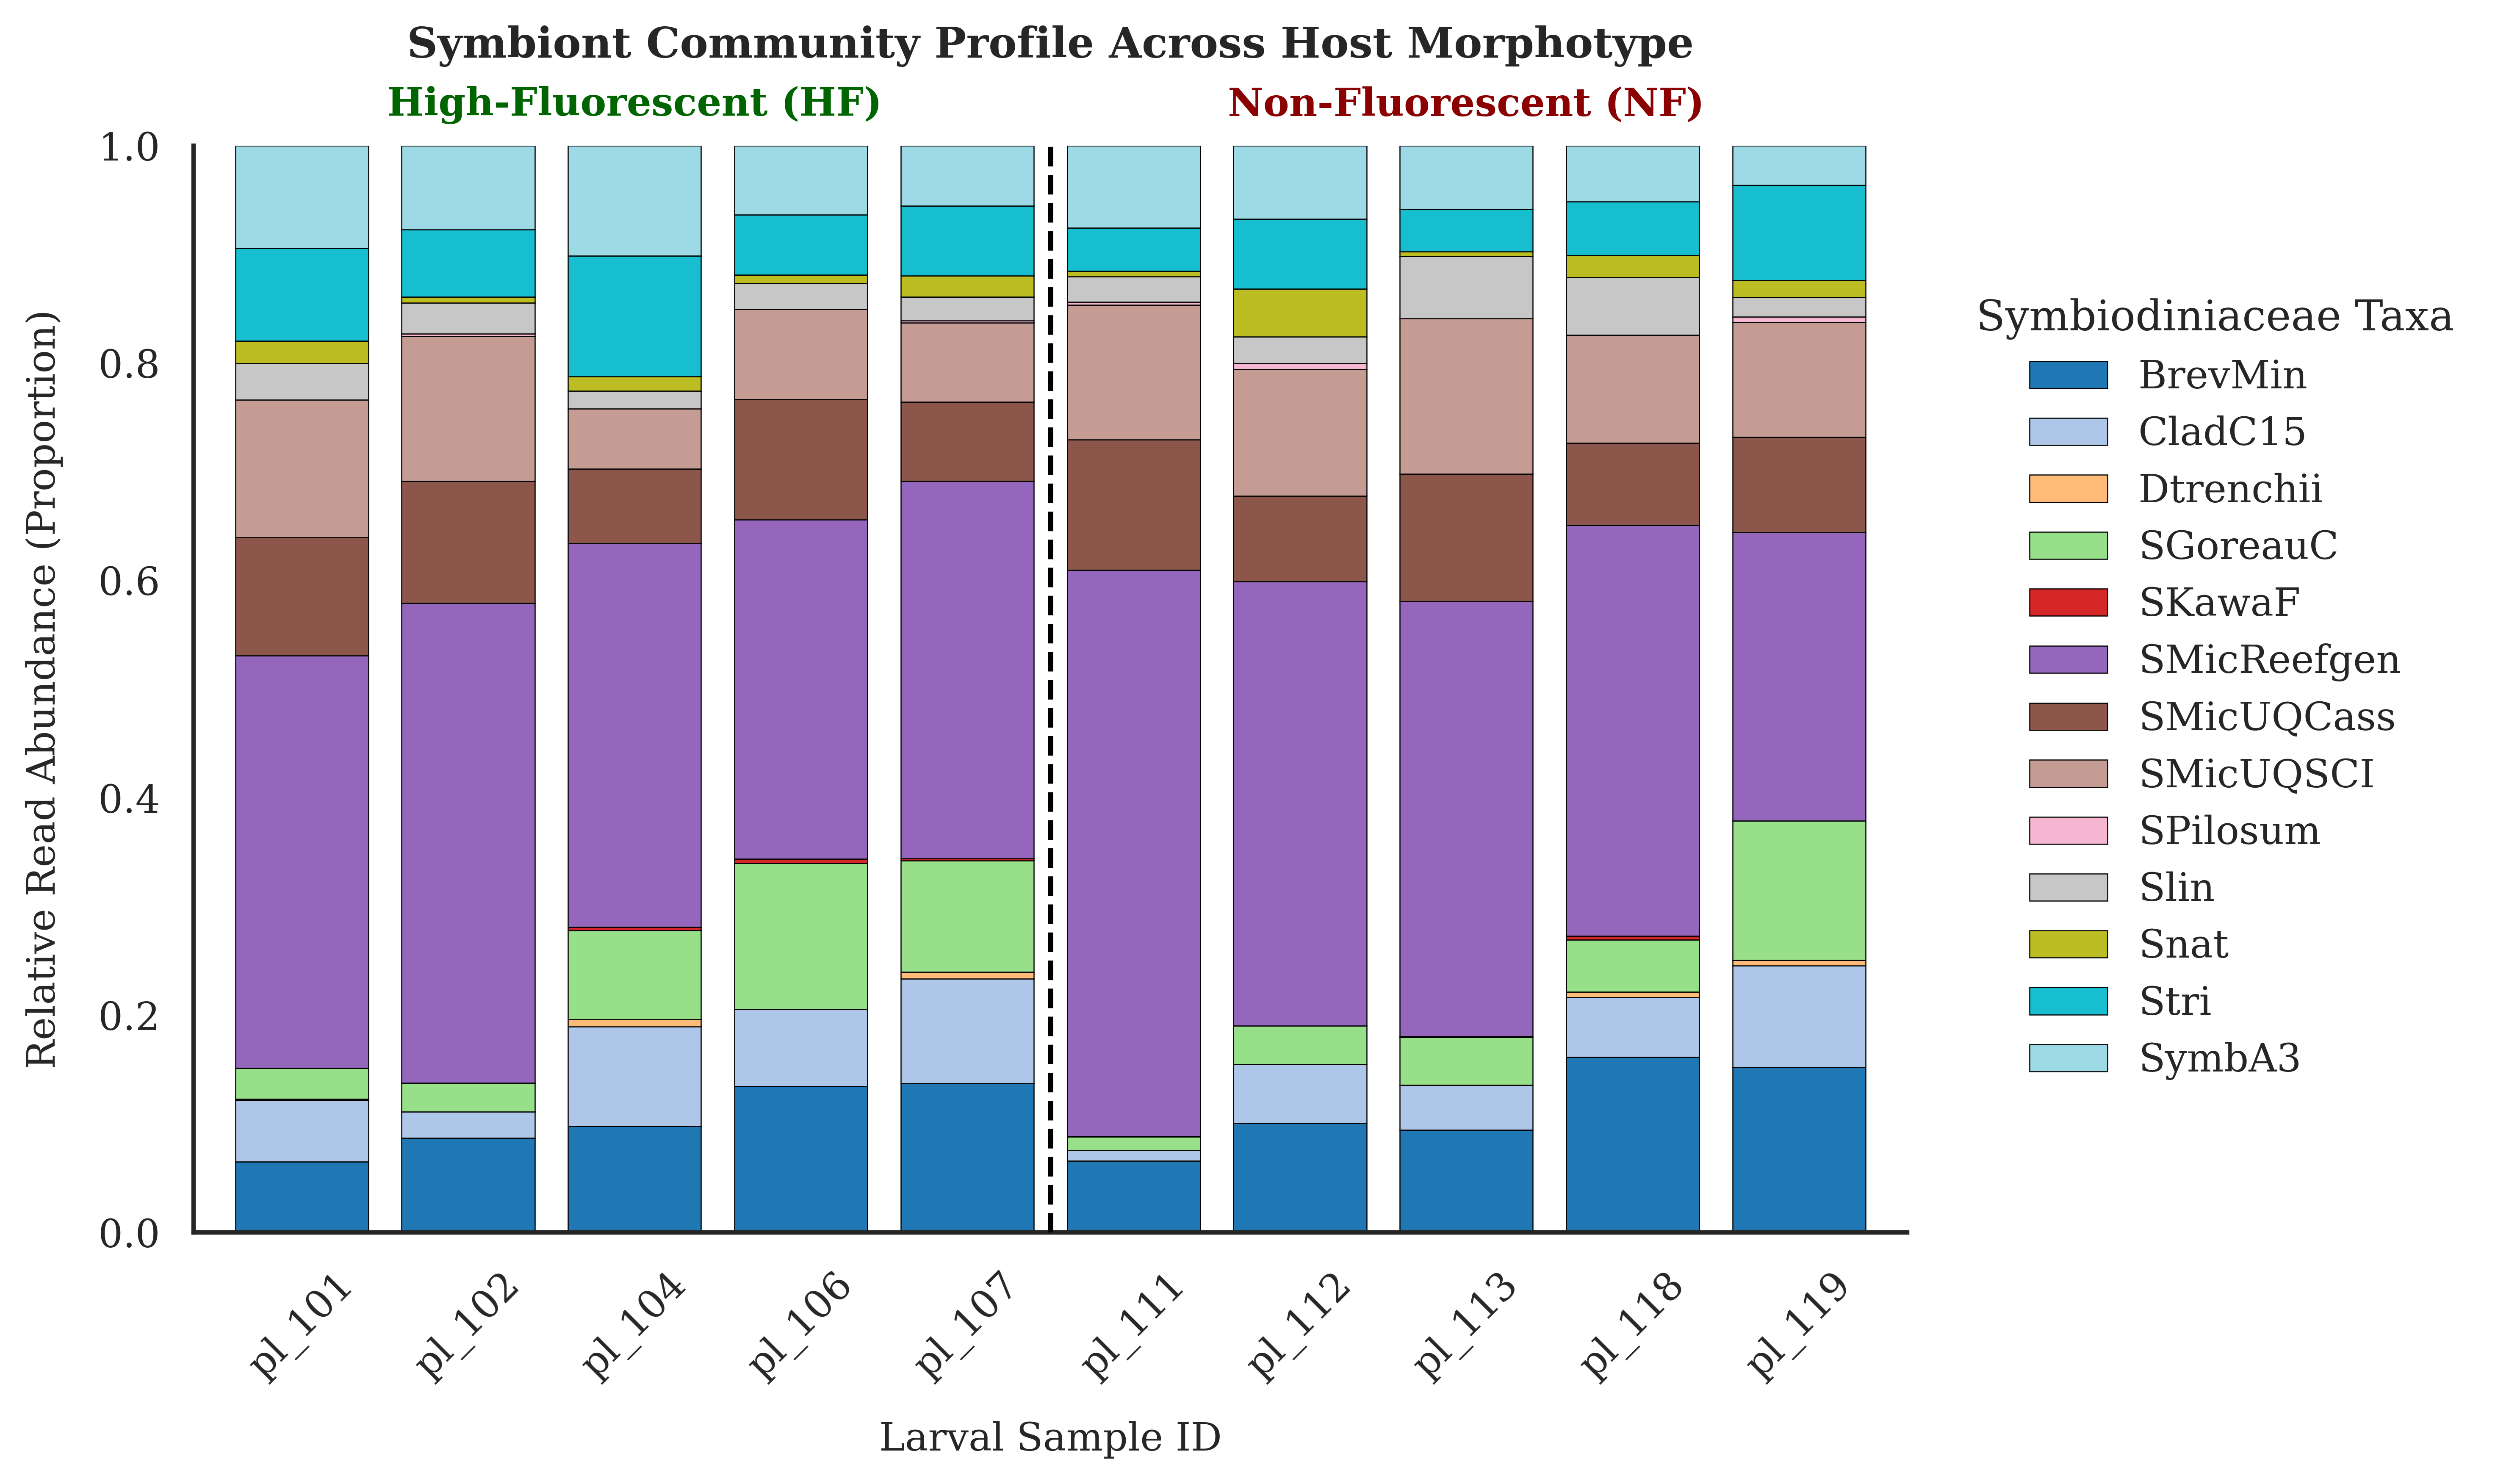

In [31]:
#BLOCK 3: Single Canvas Stacked Bar Chart with Group Divider Line

# 1. Isolate the taxa columns for plotting
taxa_cols = [col for col in df.columns if col not in ['sample', 'morph']]

# Set the 'sample' column as our index so it serves as the X-axis labels
df_plot = df.set_index('sample')

# 2. Count exactly how many HF samples we have to place the line accurately
num_hf = len(df[df['morph'] == 'HF'])

# Initialize a clean, wide standalone figure
fig, ax = plt.subplots(figsize=(10, 6))

# Define a high-quality scientific color map
color_map = plt.cm.get_cmap('tab20', len(taxa_cols))

# 3. Plot all samples together on a single canvas
df_plot[taxa_cols].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=color_map.colors,
    width=0.8,
    edgecolor='black',
    linewidth=0.3
)

# 4. DRAW THE DIVIDER LINE
# In a categorical bar chart, the spaces between bars are integers.
# The line goes exactly halfway between the last HF bar and first NF bar.
divider_position = num_hf - 0.5
ax.axvline(x=divider_position, color='black', linestyle='--', linewidth=1.5, zorder=4)

# 5. ADD TERRITORY LABELS AT THE TOP
# Place text labels at 102% of the chart height so they float cleanly above the bars
ax.text(num_hf / 2 - 0.5, 1.02, 'High-Fluorescent (HF)',
        fontsize=11, fontweight='bold', color='darkgreen', ha='center', va='bottom')

total_samples = len(df)
ax.text(num_hf + (total_samples - num_hf) / 2 - 0.5, 1.02, 'Non-Fluorescent (NF)',
        fontsize=11, fontweight='bold', color='darkred', ha='center', va='bottom')

# 6. Formatting Axis and Borders
ax.set_title('Symbiont Community Profile Across Host Morphotype', fontsize=12, fontweight='bold', pad=25)
ax.set_xlabel('Larval Sample ID', fontsize=11, labelpad=10)
ax.set_ylabel('Relative Read Abundance (Proportion)', fontsize=11, labelpad=10)
ax.set_ylim(0, 1.0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=45)

# Place the legend neatly to the right of the figure frame
ax.legend(loc='center left', title='Symbiodiniaceae Taxa', bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.savefig('Symbiont_Composition_with_Divider.png', bbox_inches='tight', dpi=600)
plt.show()

# Block 4: Layout Option B – Clean Group Averages
This block compresses all 16 rows into just two columns comparing the mean compositional baseline of your morphs. This option is ideal for your main manuscript text because it communicates your core message immediately without visual clutter.

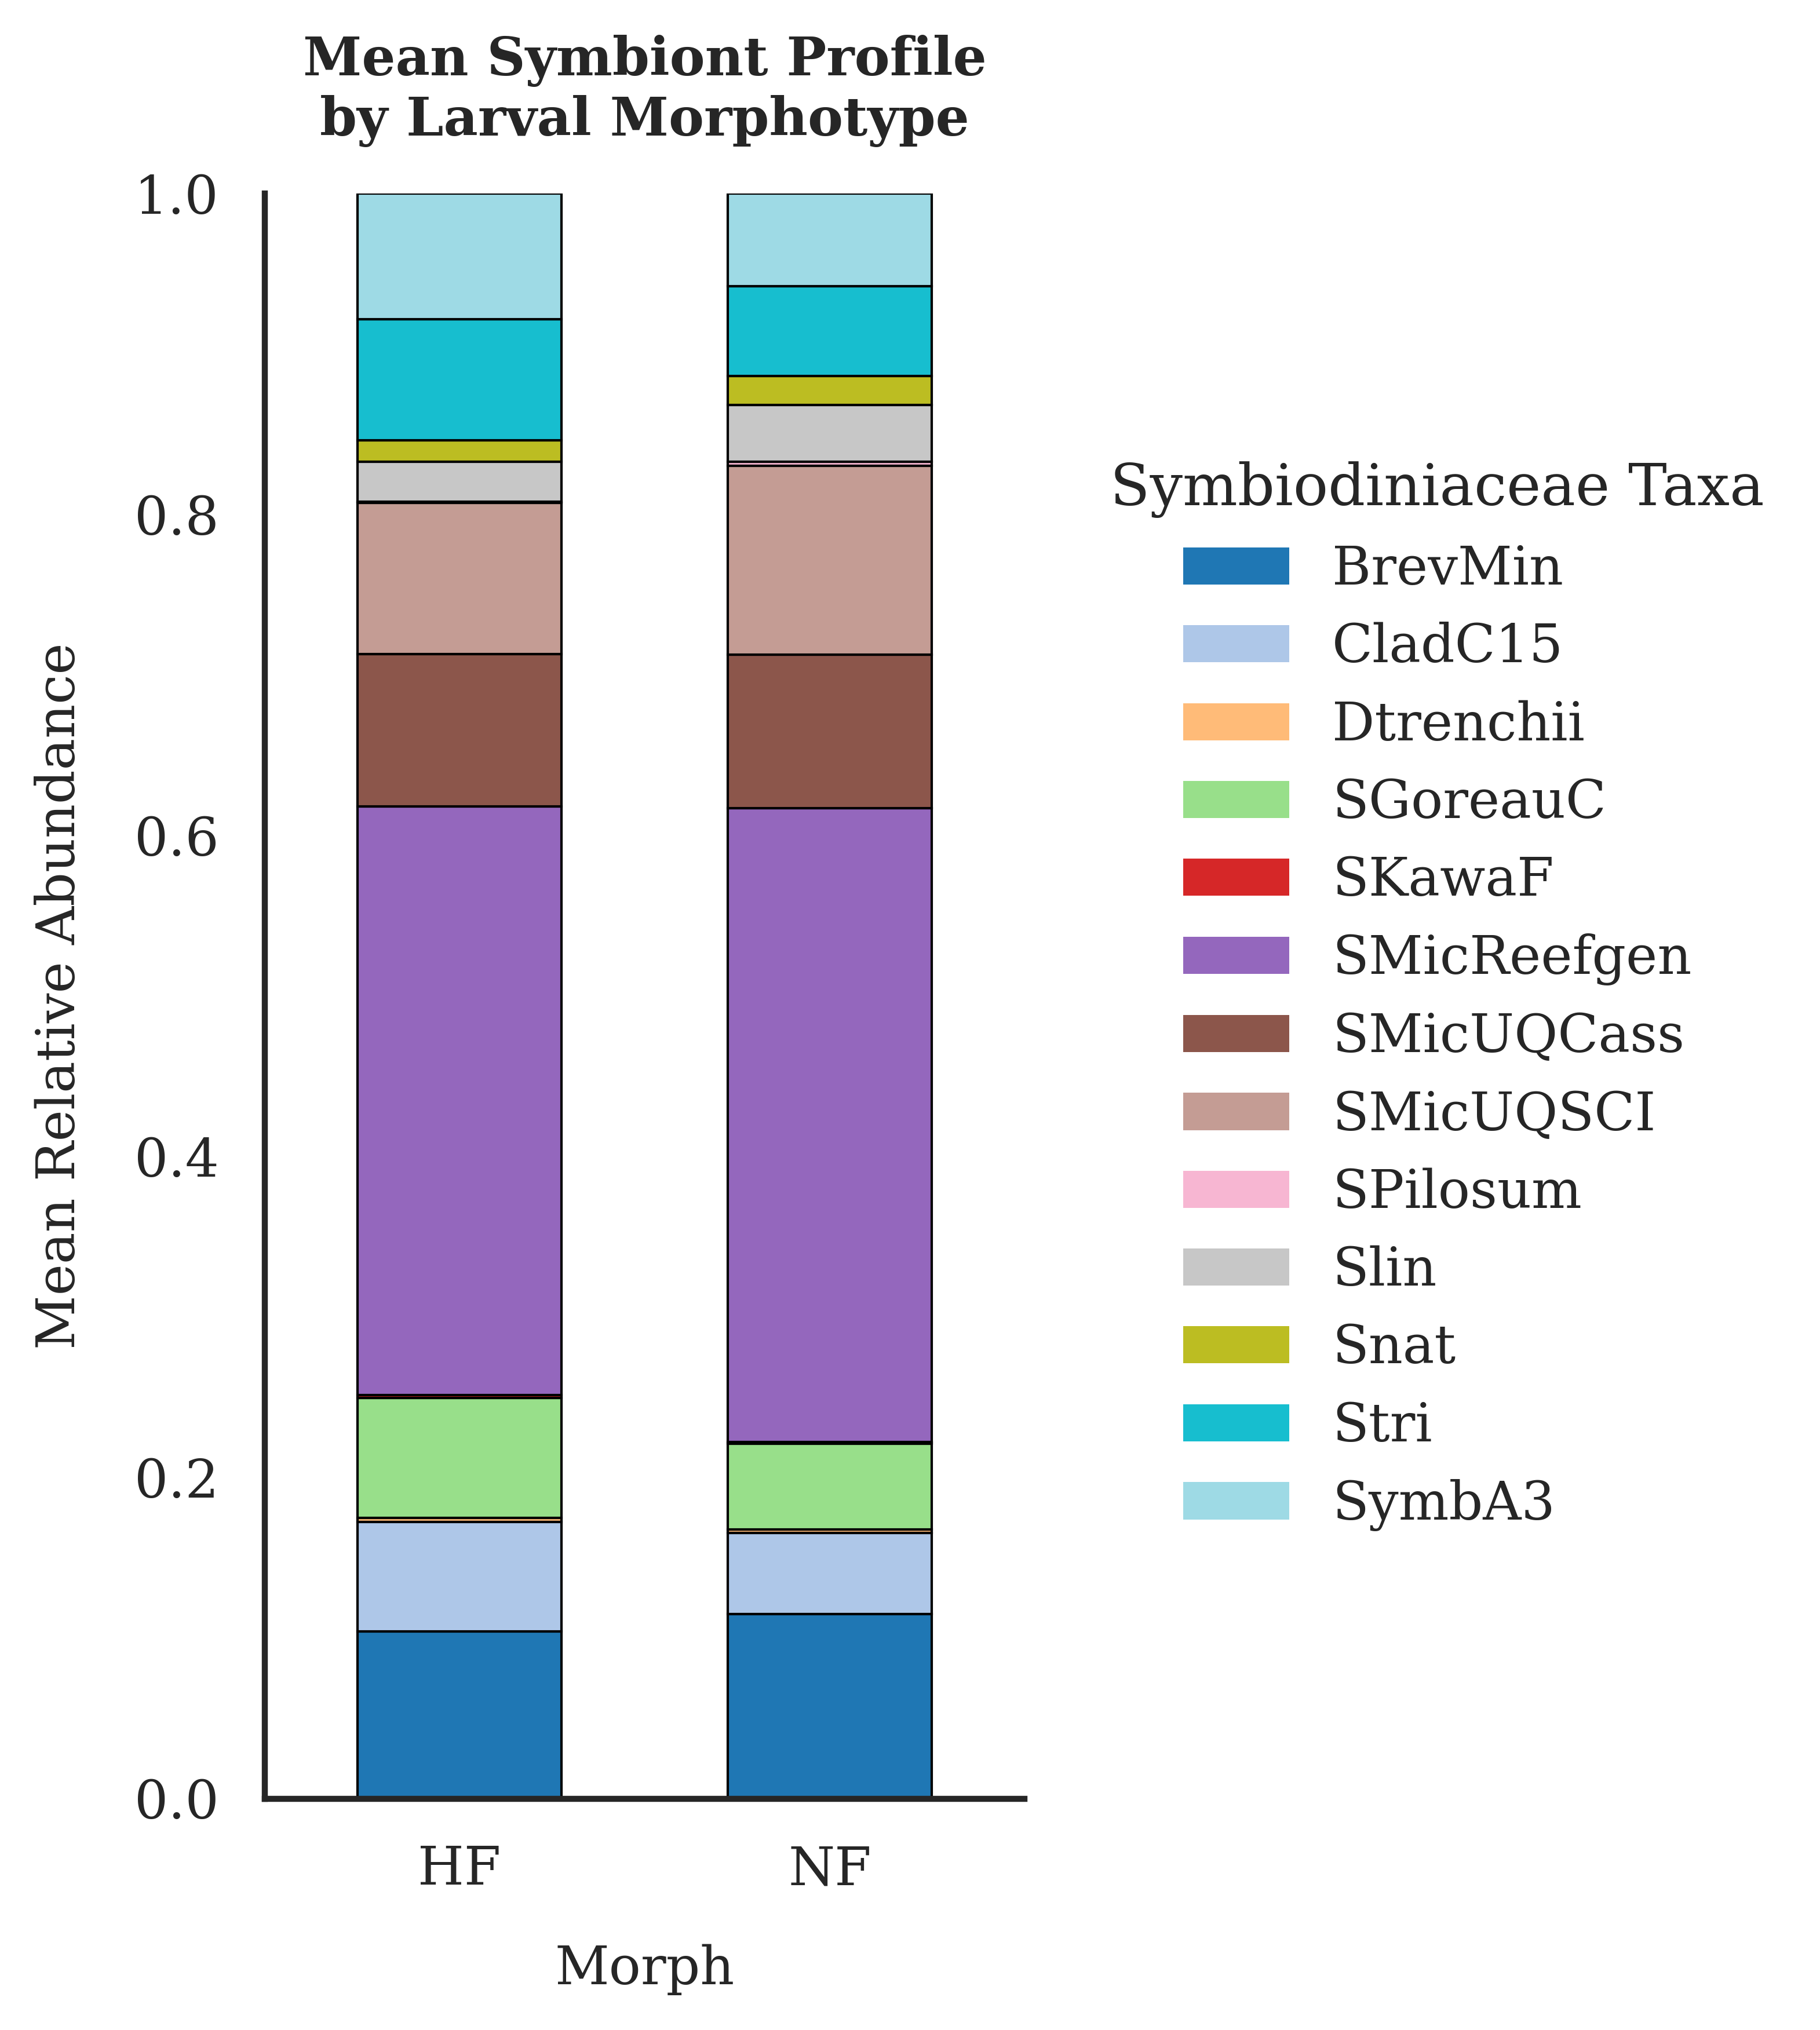

In [32]:
# BLOCK 4: Aggregated Group Mean Composition (Two-Bar Chart)

# Calculate the mean relative abundance across host categories
df_means = df.groupby('morph')[taxa_cols].mean()

# Reorder indices to align with your standard presentation flow
df_means = df_means.reindex(['HF', 'NF'])

# Initialize single-frame canvas layout
fig, ax = plt.subplots(figsize=(5.5, 6))

# Plot aggregated profiles side-by-side
df_means.plot(kind='bar', stacked=True, ax=ax, color=color_map.colors, width=0.55, edgecolor='black', linewidth=0.5)

# Add clear structural typography and axis constraints
ax.set_title('Mean Symbiont Profile\nby Larval Morphotype', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Morph', fontsize=11, labelpad=10)
ax.set_ylabel('Mean Relative Abundance', fontsize=11, labelpad=10)
ax.set_ylim(0, 1.0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=0)

# Anchor the concise legend framework
ax.legend(handles, labels, loc='center left', title='Symbiodiniaceae Taxa', bbox_to_anchor=(1.05, 0.5), frameon=False)

plt.tight_layout()
plt.savefig('Symbiont_Composition_Group_Averages.tiff', bbox_inches='tight', dpi=300)
plt.show()

# BLOCK 5: Multivariate PERMANOVA & Univariate Strain Testing

In [33]:
# BLOCK 5: Multivariate PERMANOVA & Univariate Strain Testing

# 1. Install scikit-bio to handle ecicological distance matrices
!pip install scikit-bio --quiet

from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

print("🔄 Computing community matrices...")

# 2. RUN MULTIVARIATE PERMANOVA
# Extract purely the relative abundance matrix data
matrix_data = df[taxa_cols].values

# Calculate a standard ecological Bray-Curtis dissimilarity matrix
bray_curtis_distances = pdist(matrix_data, metric='braycurtis')
distance_matrix_square = squareform(bray_curtis_distances)

# Convert to a scikit-bio tracking matrix framework
skb_dm = DistanceMatrix(distance_matrix_square, ids=df['sample'].tolist())

# Execute PERMANOVA with 999 random permutations to test host morph grouping
permanova_results = permanova(skb_dm, grouping=df['morph'].tolist(), permutations=999)

print("\n🌿 --- MULTIVARIATE COMMUNITY STATISTICS ---")
print(f"PERMANOVA Pseudo-F statistic: {permanova_results['test statistic']:.4f}")
print(f"PERMANOVA p-value:            {permanova_results['p-value']:.4f}")

# 3. RUN UNIVARIATE TEST ON THE DOMINANT TAXON
# Identify the strain with the highest global mean across your rows
dominant_strain = df[taxa_cols].mean().idxmax()

hf_strain_vals = df[df['morph'] == 'HF'][dominant_strain]
nf_strain_vals = df[df['morph'] == 'NF'][dominant_strain]

# Validate distribution shape via Shapiro-Wilk test
_, p_hf = shapiro(hf_strain_vals)
_, p_nf = shapiro(nf_strain_vals)

print(f"\n🧬 --- TARGETED UNIVARIATE STATISTICS ({dominant_strain}) ---")
if p_hf > 0.05 and p_nf > 0.05:
    # Parametric assessment
    t_stat, uni_p = ttest_ind(hf_strain_vals, nf_strain_vals, equal_var=False)
    print(f"Welch's T-test statistic: {t_stat:.4f}")
    print(f"T-test p-value:           {uni_p:.4f}")
else:
    # Non-parametric fallback assessment
    u_stat, uni_p = mannwhitneyu(hf_strain_vals, nf_strain_vals)
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"Mann-Whitney p-value:     {uni_p:.4f}")

🔄 Computing community matrices...

🌿 --- MULTIVARIATE COMMUNITY STATISTICS ---
PERMANOVA Pseudo-F statistic: 0.7412
PERMANOVA p-value:            0.4730

🧬 --- TARGETED UNIVARIATE STATISTICS (SMicReefgen) ---
Welch's T-test statistic: -0.6116
T-test p-value:           0.5630


# Block 6: Matrix Filtering & Group Mapping
This cell reads your expression spreadsheet, pulls out your specific target genes, transposes the structure, and binds your balanced biological replicates ($n=5$ High-Fluorescent vs. $n=5$ Non-Fluorescent) to their proper phenotypes.

In [34]:

# 1. Load the raw regularized log-transformed count matrix
rlog_df = pd.read_csv('rlog.counts.csv', index_col=0)
rlog_df.columns = rlog_df.columns.str.strip()

# 2. Set the explicit balanced replication layout (N = 10 total planulae)
hf_group = ['pl_101', 'pl_102', 'pl_104', 'pl_106', 'pl_107']
nf_group = ['pl_111', 'pl_112', 'pl_113', 'pl_118', 'pl_119']
experimental_samples = hf_group + nf_group

# 3. Target your cryptic amFP486 green fluorescent chromoprotein biomarkers
gfp_loci = ['LOC111346784', 'LOC111344518']

# Filter, transpose, and structure your tidy working matrix
df_gfp = rlog_df.loc[gfp_loci, experimental_samples].T.reset_index()
df_gfp.rename(columns={'index': 'sample'}, inplace=True)

# Assign conditional categorical cohort markers
df_gfp['morph'] = np.where(df_gfp['sample'].isin(hf_group), 'HF', 'NF')
df_gfp = df_gfp.sort_values(by=['morph', 'sample']).reset_index(drop=True)

print("📊 Block 2: Filtered transcriptional subset compiled:")
print(df_gfp)

📊 Block 2: Filtered transcriptional subset compiled:
   sample  LOC111346784  LOC111344518 morph
0  pl_101      3.895343      3.146035    HF
1  pl_102      3.711994      3.075049    HF
2  pl_104      5.088106      3.559639    HF
3  pl_106      4.866620      4.573439    HF
4  pl_107      3.940657      3.246406    HF
5  pl_111      2.554911      2.528381    NF
6  pl_112      2.911387      2.313016    NF
7  pl_113      2.406407      2.038195    NF
8  pl_118      2.622172      2.250179    NF
9  pl_119      2.725745      2.170540    NF


# Block 7: Group-Wise Normality Sweeps
This cell carries out independent Shapiro-Wilk normality checking for each gene and each color phenotype separately. This mathematically establishes whether  distributions are normal or skewed.

In [35]:
print("🔬 CONDUCTING ASSUMPTION CHECKS (Alpha threshold = 0.05)...")
normality_registry = {}

for target_gene in gfp_loci:
    hf_array = df_gfp[df_gfp['morph'] == 'HF'][target_gene].values
    nf_array = df_gfp[df_gfp['morph'] == 'NF'][target_gene].values

    # Calculate Shapiro-Wilk profiles
    _, hf_p_val = shapiro(hf_array)
    _, nf_p_val = shapiro(nf_array)

    # Store booleans: True means normal (p > 0.05), False means skewed (p <= 0.05)
    normality_registry[f"{target_gene}_HF"] = hf_p_val > 0.05
    normality_registry[f"{target_gene}_NF"] = nf_p_val > 0.05

    print(f"\n🧬 Target Location: {target_gene}")
    print(f"   - HF Morph Pool Distribution p-value: {hf_p_val:.4f} -> {'Normal' if hf_p_val > 0.05 else 'Skewed'}")
    print(f"   - NF Morph Pool Distribution p-value: {nf_p_val:.4f} -> Navigating layout change... {'Normal' if nf_p_val > 0.05 else 'Skewed'}")

🔬 CONDUCTING ASSUMPTION CHECKS (Alpha threshold = 0.05)...

🧬 Target Location: LOC111346784
   - HF Morph Pool Distribution p-value: 0.1521 -> Normal
   - NF Morph Pool Distribution p-value: 0.9888 -> Navigating layout change... Normal

🧬 Target Location: LOC111344518
   - HF Morph Pool Distribution p-value: 0.0642 -> Normal
   - NF Morph Pool Distribution p-value: 0.9441 -> Navigating layout change... Normal


# Block 8: Statistical Evaluation Core
This cell computes your downstream statistical models. It automatically runs a parametric Welch's t-test (degrees of freedom = 8) if the data is normal, or switches to a non-parametric Mann-Whitney U rank-sum check if any group distribution shows skewness.

In [36]:

statistical_outputs = {}

print("🌿 CALCULATING MORPHOTYPE COMPARISONS...")
for target_gene in gfp_loci:
    hf_array = df_gfp[df_gfp['morph'] == 'HF'][target_gene].values
    nf_array = df_gfp[df_gfp['morph'] == 'NF'][target_gene].values

    print(f"\nLocus: {target_gene}")

    # If both groups are normal, proceed with parametric comparison
    if normality_registry[f"{target_gene}_HF"] and normality_registry[f"{target_gene}_NF"]:
        test_stat, p_result = ttest_ind(hf_array, nf_array, equal_var=False)
        statistical_outputs[target_gene] = p_result
        print(f"   - Test Strategy: Welch's independent t-test (Parametric)")
        print(f"   - Calculated t-value: {test_stat:.4f}")
        print(f"   - Resulting p-value:  {p_result:.6f}")
    else:
        # Fallback to distribution-free rank analysis if assumptions are violated
        test_stat, p_result = mannwhitneyu(hf_array, nf_array, alternative='two-sided')
        statistical_outputs[target_gene] = p_result
        print(f"   - Test Strategy: Mann-Whitney U test (Non-Parametric)")
        print(f"   - Calculated U-value: {test_stat:.4f}")
        print(f"   - Resulting p-value:  {p_result:.6f}")

🌿 CALCULATING MORPHOTYPE COMPARISONS...

Locus: LOC111346784
   - Test Strategy: Welch's independent t-test (Parametric)
   - Calculated t-value: 5.6421
   - Resulting p-value:  0.002921

Locus: LOC111344518
   - Test Strategy: Welch's independent t-test (Parametric)
   - Calculated t-value: 4.3788
   - Resulting p-value:  0.008306


# Block 9: Peer-Review Ready Visualization
This cell reshapes your variables into a melted long-format table and builds a clean publication figure. It plots boxplots to track group distributions, overlays translucent jittered dots to show all 10 raw biological replicates, and plots bold significance indicators directly above the candidate target genes.

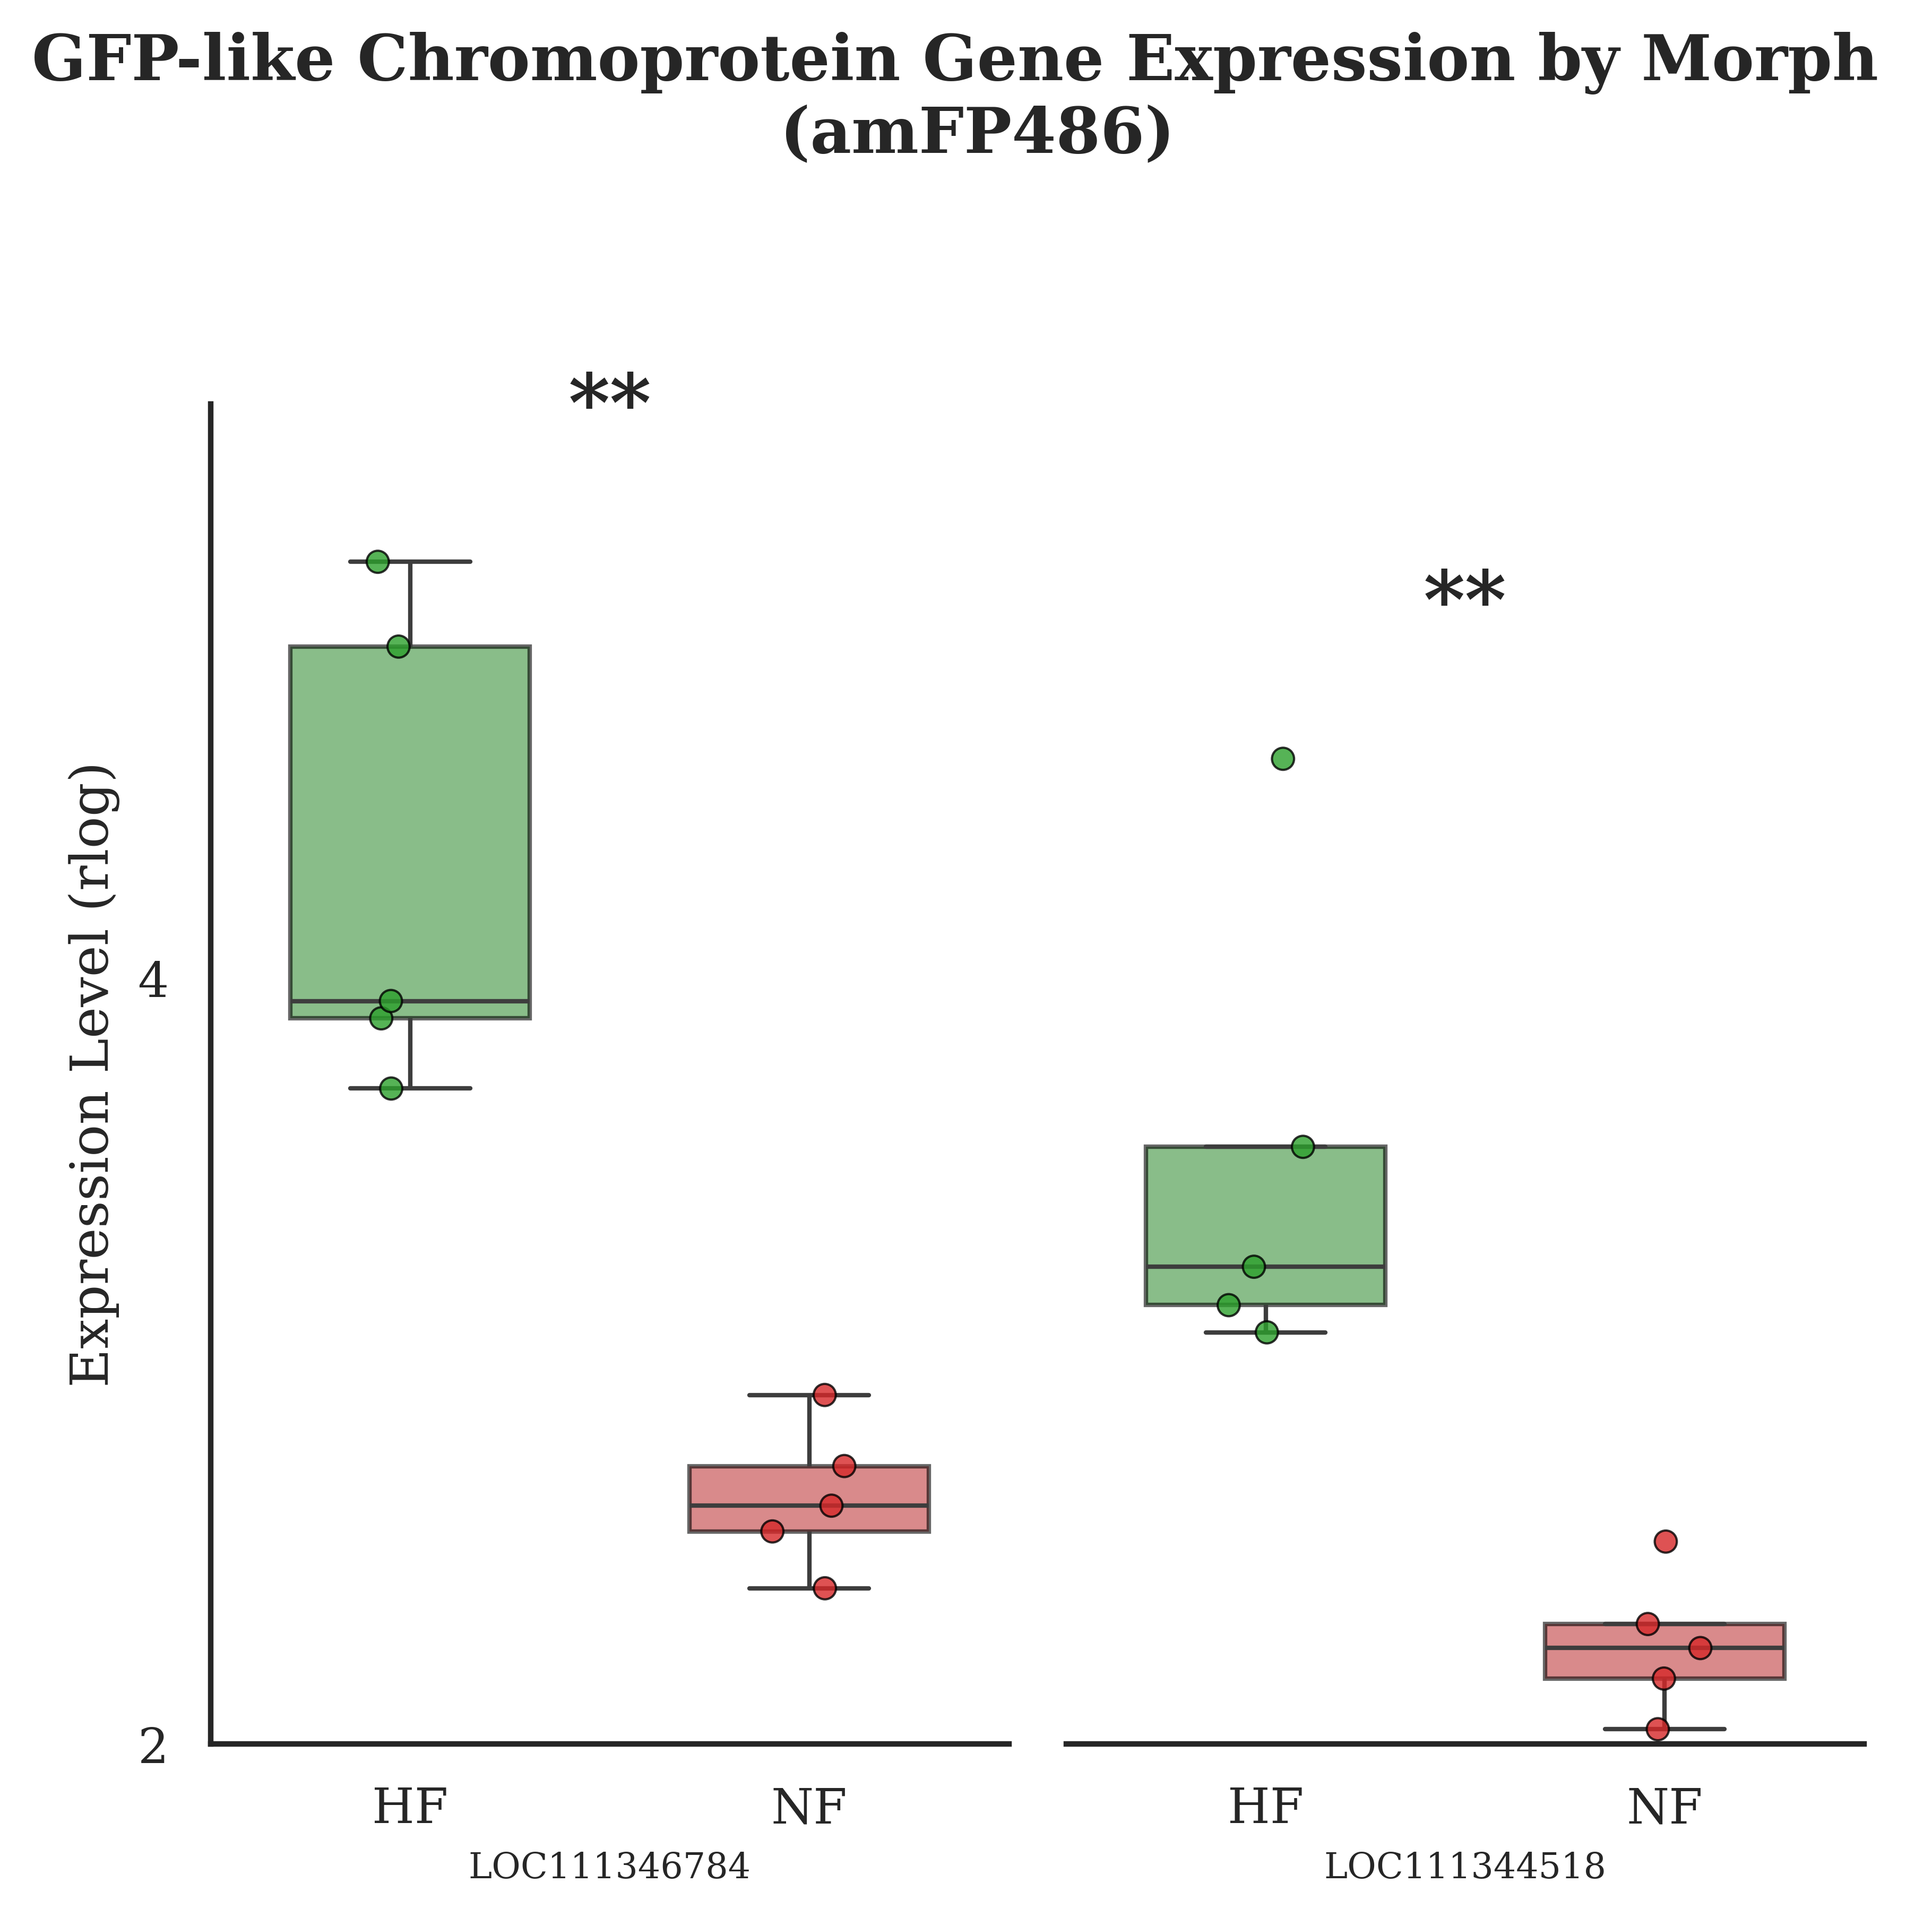

In [51]:
# Block 9: Updated Peer-Review Visualization with Global Styling
morph_order = ['HF', 'NF']

# Melt the DataFrame to long format
df_melted = df_gfp.melt(id_vars=['sample', 'morph'],
                        value_vars=gfp_loci,
                        var_name='Locus', value_name='Expression')

# Create FacetGrid using global aspect ratios and theme settings
g = sns.catplot(data=df_melted, x='morph', y='Expression', col='Locus',
                kind='box', col_order=df_melted['Locus'].unique(),
                hue='morph', palette=variant_colors, order=morph_order,
                boxprops=dict(alpha=global_alpha, edgecolor='black', linewidth=1),
                showmeans=False, showfliers=False,
                height=global_fig_size[1], aspect=0.5, sharey=True, width=0.6)

# Add stripplot to each facet using global jitter and marker settings
g.map_dataframe(sns.stripplot, x='morph', y='Expression',
                hue='morph', palette=variant_colors, order=morph_order,
                jitter=global_jitter, size=global_marker_size, dodge=False,
                edgecolor='black', linewidth=0.5, alpha=0.8)

g.set_axis_labels("", "Expression Level (rlog)")
g.set_titles("")

# Map LOC IDs to human-readable names
locus_labels = {
    'LOC111346784': 'LOC111346784',
    'LOC111344518': 'LOC111344518'
}

# Helper function for significance symbols
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

min_exp = df_melted['Expression'].min()

for i, ax in enumerate(g.axes.flat):
    current_locus_id = df_melted['Locus'].unique()[i]
    current_locus_name = locus_labels.get(current_locus_id, current_locus_id)

    # Use global nbins for cleaner y-axis
    ax.locator_params(axis='y', nbins=global_y_nbins)
    ax.set_ylim(bottom=np.floor(min_exp), top=5.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if i > 0:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False, left=False)
        ax.spines['left'].set_visible(False)

    # Set smaller font size for locus labels
    ax.set_xlabel(current_locus_name, fontsize=8)

    # Add Significance Asterisks using global asterisk settings
    p_val = statistical_outputs.get(current_locus_id, 1.0)
    star_text = get_stars(p_val)

    facet_max = df_melted[df_melted['Locus'] == current_locus_id]['Expression'].max()
    ax.text(0.5, facet_max + 0.3, star_text, ha='center', va='bottom',
            fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

# UPDATED: Set title to bold weight and adjusted y position
plt.suptitle('GFP-like Chromoprotein Gene Expression by Morph \n (amFP486)', y=1.0, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('GFP_Expression_Global_Style.png', dpi=600, bbox_inches='tight')
plt.show()

### Block 10: Combined Multi-Panel Analysis (Panel A & B)
This figure integrates the transcriptional biomarkers and symbiont community data into a single side-by-side visualization with academic panel labels.